# Exploratory Data Analysis and Data Quality Assessment

## Notebook 02: CarDekho Used-Car Dataset

**Author:** Muhammad Waqas  
**Target Variable:** `Price`  
**Previous Notebook:** `01_data_understanding.ipynb`

## Objective

The objective of this notebook is to visually and statistically investigate
the distributions, relationships, unusual observations, and data-quality
issues in the CarDekho used-car dataset.

This analysis will examine:

- The distribution and skewness of Price
- Numerical feature distributions and outliers
- Categorical feature frequencies
- Relationships between vehicle characteristics and Price
- Suspicious mileage observations
- High-cardinality features
- Correlation and multicollinearity
- Possible transformations and feature-engineering requirements

## Research Focus

The analysis will help determine:

1. Which vehicle characteristics are associated with Price?
2. Whether the Price distribution requires logarithmic transformation
3. Whether extreme values are valid observations or likely data errors
4. Which features require cleaning, extraction, grouping, or removal
5. Which preprocessing decisions should be carried into the modeling pipeline

## Notebook Boundary

This notebook performs exploratory analysis only.

Final imputation, categorical encoding, feature scaling, train-test splitting,
and model training will be implemented in later notebooks through reproducible
pipelines to prevent data leakage.

## 1. Import Required Libraries and Load the Dataset



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [4]:
file_path = "../data/raw/car_price_data.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)


Dataset loaded successfully.
Dataset shape: (2059, 20)


## 2. Statistical Profile of the Target Variable

The Price variable is examined before visualization to measure its range,
central tendency, variation, and skewness.

Target distribution is important because strong skewness and extreme values
can affect Linear Regression assumptions, residuals, and error metrics.

In [5]:
price_summary = df["Price"].describe().round(2)
price_skewness = df["Price"].skew()

print(price_summary)
print("\nPrice skewness:", round(price_skewness, 2))

count        2059.00
mean      1702991.70
std       2419880.64
min         49000.00
25%        484999.00
50%        825000.00
75%       1925000.00
max      35000000.00
Name: Price, dtype: float64

Price skewness: 4.97


### Target Statistical Observation

- Price has a strong positive skewness of 4.97.
- The mean Price is substantially higher than the median Price.
- Most vehicles are concentrated in the lower and middle price ranges.
- A relatively small number of luxury vehicles creates a long right tail.
- Original Price and log-transformed Price will both be evaluated during
  modeling rather than automatically removing expensive vehicles.

## 3. Distribution of Vehicle Prices

A histogram shows how vehicle prices are distributed across the dataset.
Prices are displayed in millions for easier interpretation.

The KDE curve provides a smooth estimate of the distribution shape.

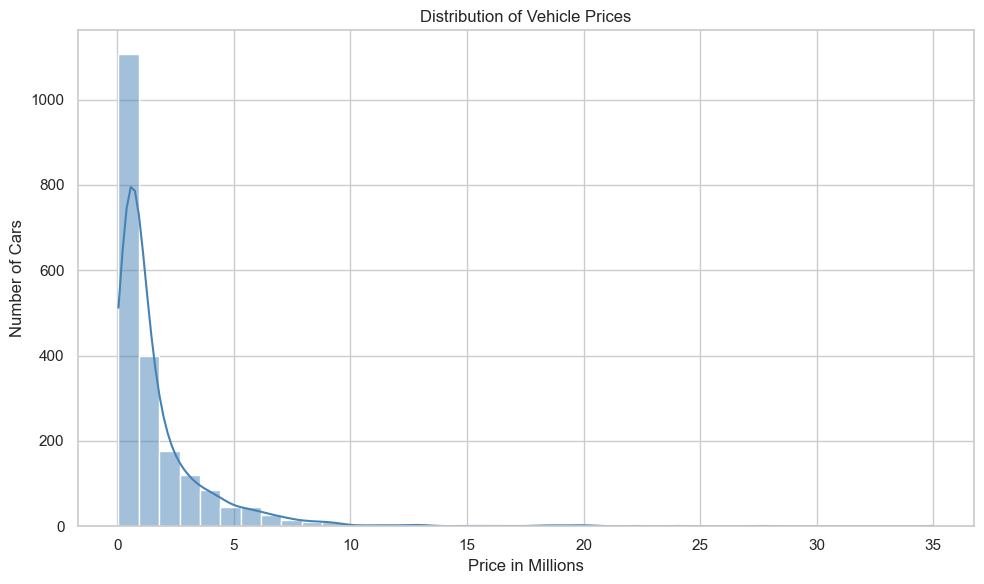

In [6]:
price_in_millions = df["Price"] / 1_000_000

plt.figure(figsize=(10, 6))

sns.histplot(
    price_in_millions,
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Vehicle Prices")
plt.xlabel("Price in Millions")
plt.ylabel("Number of Cars")

plt.tight_layout()

plt.savefig(
    "../results/figures/price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Price-Distribution Observation

The histogram confirms that most vehicles are concentrated in the lower
price range, while a small number of luxury vehicles extends the distribution
to approximately 35 million.

The long right tail makes the original Price distribution highly skewed.
Because these expensive observations represent valid luxury vehicles, they
will be retained.

A logarithmic Price transformation will now be examined to reduce skewness
without deleting valid observations.

## 4. Log-Transformed Price Distribution

A logarithmic transformation compresses large values more strongly than
small values. It can reduce target skewness while retaining all valid
vehicle records.

The transformation is used only as an experiment. Original and log-target
models will later be compared on the original Price scale.

Original Price skewness: 4.97
Log Price skewness: 0.49


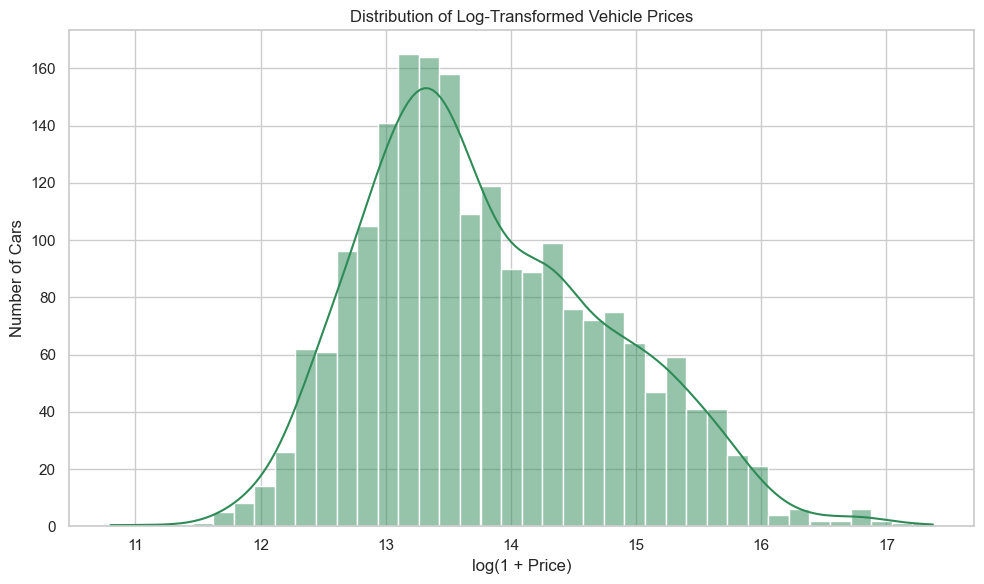

In [7]:
log_price = np.log1p(df["Price"])

print("Original Price skewness:", round(df["Price"].skew(), 2))
print("Log Price skewness:", round(log_price.skew(), 2))

plt.figure(figsize=(10, 6))

sns.histplot(
    log_price,
    bins=40,
    kde=True,
    color="seagreen"
)

plt.title("Distribution of Log-Transformed Vehicle Prices")
plt.xlabel("log(1 + Price)")
plt.ylabel("Number of Cars")

plt.tight_layout()

plt.savefig(
    "../results/figures/log_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Log-Transformation Finding

- Log transformation reduced Price skewness from 4.97 to 0.49.
- The transformed distribution is substantially more balanced and closer
  to symmetry.
- The extreme luxury-vehicle prices remain in the dataset but have less
  influence on the transformed scale.
- The distribution still shows some structure and is not perfectly normal.
- Both original-target and log-target models will be trained and compared.
- Predictions from the log-target model will be converted back to the
  original Price scale before final evaluation.

## 5. Distribution of Manufacturing Year

The Year distribution is examined to understand the age coverage of vehicles
and whether the dataset is dominated by recent or older cars.

Vehicle year is expected to have an important relationship with Price.

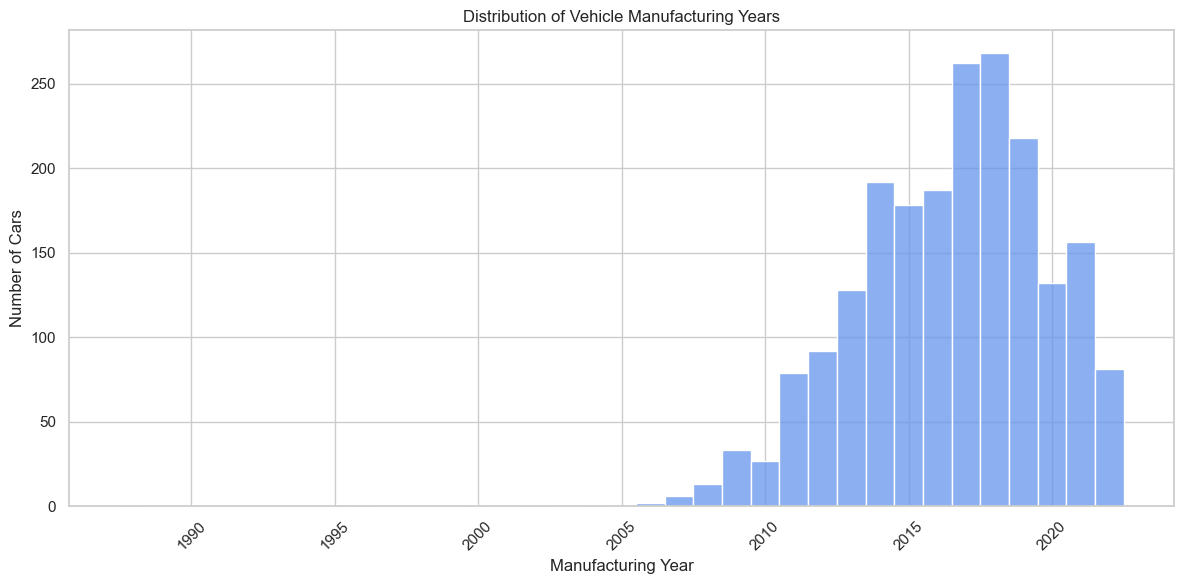

In [8]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Year",
    discrete=True,
    color="cornflowerblue"
)

plt.title("Distribution of Vehicle Manufacturing Years")
plt.xlabel("Manufacturing Year")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../results/figures/year_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Manufacturing-Year Observation

- Most vehicles were manufactured between approximately 2012 and 2021.
- The largest concentration occurs around 2017 and 2018.
- Vehicles manufactured before 2010 are underrepresented.
- The model may therefore generalize better to recent vehicles than to
  substantially older vehicles.
- Vehicle age is likely to be more interpretable than the raw manufacturing
  year for explaining depreciation.

### 5.1 Vehicle-Age Proxy

The dataset does not contain an explicit listing date. Therefore, the maximum
manufacturing year in the dataset is used as a reference year to create an
approximate vehicle-age feature.

This is an exploratory proxy and not a confirmed age at the time of sale.

In [9]:
reference_year = df["Year"].max()

df["Vehicle Age"] = reference_year - df["Year"]

print("Reference year:", reference_year)
print("Minimum vehicle age:", df["Vehicle Age"].min())
print("Maximum vehicle age:", df["Vehicle Age"].max())

Reference year: 2022
Minimum vehicle age: 0
Maximum vehicle age: 34


## 6. Statistical Profile of Kilometer

The Kilometer variable is examined using percentiles and skewness because
its maximum value is much larger than the typical observations.

Percentiles help distinguish the normal data range from a small number of
extreme values.

In [10]:
kilometer_summary = df["Kilometer"].describe(
    percentiles=[0.90, 0.95, 0.99]
).round(2)

kilometer_skewness = df["Kilometer"].skew()

print(kilometer_summary)
print("\nKilometer skewness:", round(kilometer_skewness, 2))

count       2059.00
mean       54224.71
std        57361.72
min            0.00
50%        50000.00
90%        90000.00
95%       107991.10
99%       147100.00
max      2000000.00
Name: Kilometer, dtype: float64

Kilometer skewness: 20.98


### Kilometer Statistical Observation

- The median recorded mileage is 50,000 km.
- Ninety-nine percent of vehicles have Kilometer values at or below 147,100.
- The maximum value of 2,000,000 is substantially larger than the 99th
  percentile.
- Kilometer skewness is extremely high at 20.98.
- A very small number of observations strongly affects the mean, standard
  deviation, and visual distribution.
- These values require sensitivity analysis before a final treatment decision.

### 6.1 Full and Zoomed Kilometer Distributions

The first plot includes all records. The second plot displays observations
up to the 99th percentile to reveal the main distribution.

The zoomed plot is for visualization only. No records are deleted.

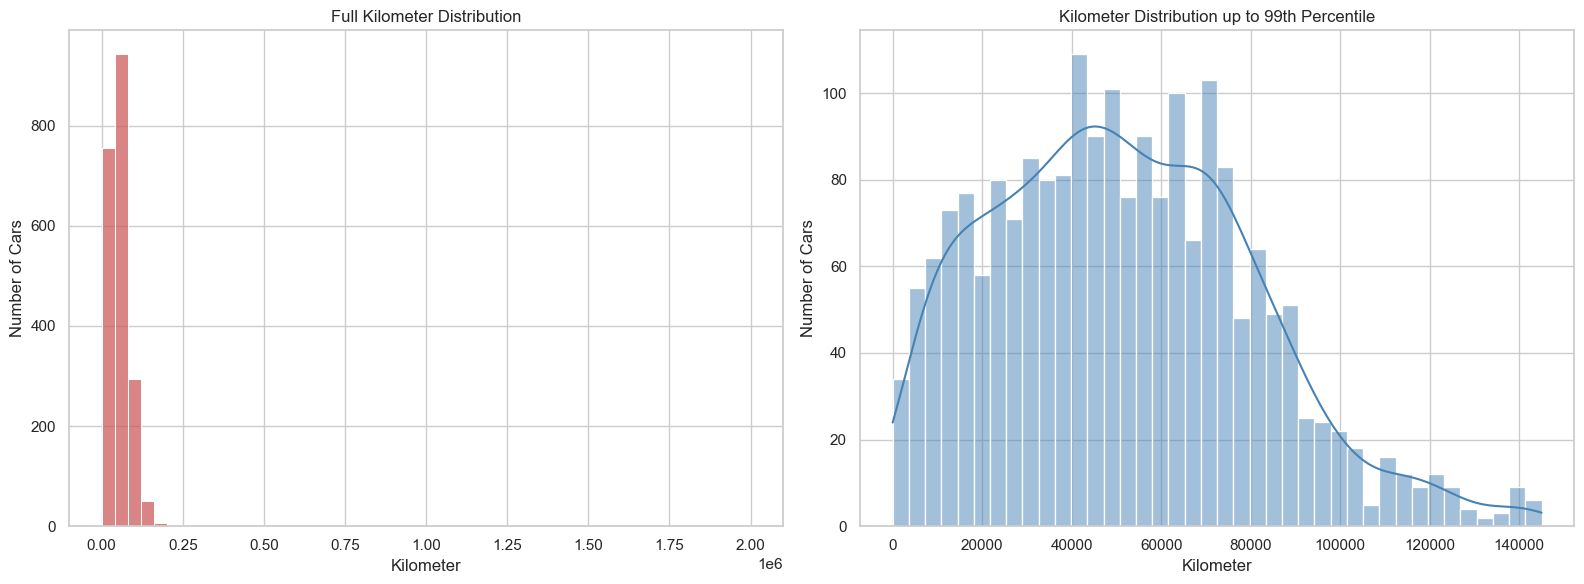

In [11]:
kilometer_99 = df["Kilometer"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=df,
    x="Kilometer",
    bins=50,
    ax=axes[0],
    color="indianred"
)

axes[0].set_title("Full Kilometer Distribution")
axes[0].set_xlabel("Kilometer")
axes[0].set_ylabel("Number of Cars")

sns.histplot(
    data=df[df["Kilometer"] <= kilometer_99],
    x="Kilometer",
    bins=40,
    kde=True,
    ax=axes[1],
    color="steelblue"
)

axes[1].set_title("Kilometer Distribution up to 99th Percentile")
axes[1].set_xlabel("Kilometer")
axes[1].set_ylabel("Number of Cars")

plt.tight_layout()

plt.savefig(
    "../results/figures/kilometer_full_and_zoomed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Kilometer-Distribution Finding

The complete histogram is dominated by a very small number of extreme
mileage observations. After zooming to the 99th percentile, the main
distribution becomes visible.

Most vehicles fall below approximately 100,000 km, with the highest
concentration around 40,000 to 70,000 km. The main distribution remains
right-skewed but is substantially more plausible than the complete view.

Potential treatments will include log transformation and sensitivity
analysis. Extreme records will not be silently deleted or corrected.

### 6.2 Log-Transformed Kilometer Distribution

A log transformation is evaluated to reduce the influence of large mileage
values. Because Kilometer contains zero values, `log1p()` is used.

Log transformation can reduce skewness, but it does not prove that suspicious
records are valid.

Original Kilometer skewness: 20.98
Log Kilometer skewness: -3.03


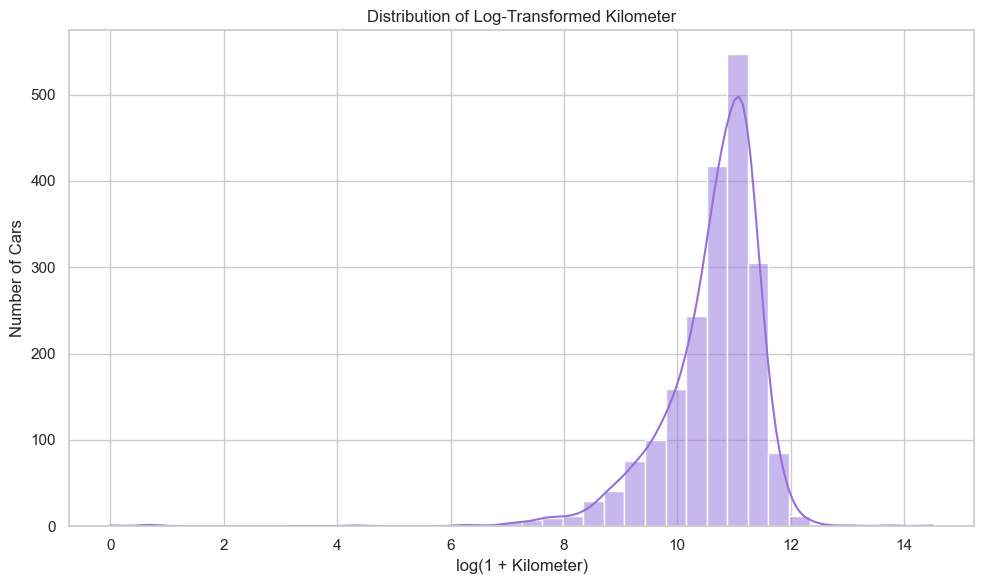

In [12]:
log_kilometer = np.log1p(df["Kilometer"])

print(
    "Original Kilometer skewness:",
    round(df["Kilometer"].skew(), 2)
)

print(
    "Log Kilometer skewness:",
    round(log_kilometer.skew(), 2)
)

plt.figure(figsize=(10, 6))

sns.histplot(
    log_kilometer,
    bins=40,
    kde=True,
    color="mediumpurple"
)

plt.title("Distribution of Log-Transformed Kilometer")
plt.xlabel("log(1 + Kilometer)")
plt.ylabel("Number of Cars")

plt.tight_layout()

plt.savefig(
    "../results/figures/log_kilometer_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Log-Kilometer Finding

Log transformation compressed the extremely high Kilometer values but changed
the distribution from strong positive skewness to strong negative skewness.

The transformed skewness of -3.03 indicates that log transformation does not
provide a balanced Kilometer distribution. Zero and very-low mileage records
form a long left tail after transformation.

Therefore, log-transformed Kilometer will not automatically replace the raw
feature. Zero values and suspiciously low mileage records must first be
investigated.

### 6.3 Investigation of Zero and Low Kilometer Values

Zero and very-low mileage records are examined because they strongly affect
the log-transformed distribution.

These records may represent new, unregistered, demonstration, or incorrectly
recorded vehicles.

In [13]:
print(
    "Kilometer equal to 0:",
    (df["Kilometer"] == 0).sum()
)

print(
    "Kilometer from 1 to 100:",
    df["Kilometer"].between(1, 100).sum()
)

print(
    "Kilometer from 101 to 1000:",
    df["Kilometer"].between(101, 1000).sum()
)

low_kilometer_columns = [
    "Make",
    "Model",
    "Price",
    "Year",
    "Kilometer",
    "Owner"
]

df.sort_values(
    by="Kilometer"
)[low_kilometer_columns].head(15)

Kilometer equal to 0: 1
Kilometer from 1 to 100: 3
Kilometer from 101 to 1000: 3


,Make,Model,Price,Year,Kilometer,Owner
1766,MINI,Cooper JCW Hatchback,5200000,2022,0,UnRegistered Car
1746,Audi,A4 Premium Plus 40 TFSI,4151000,2022,1,UnRegistered Car
139,Audi,Q5 45 TFSI Premium Plus,5651000,2022,1,UnRegistered Car
2044,Mahindra,XUV700 AX 7 Petrol AT Luxury Pack 7 STR,2765000,2022,75,First
1563,Mercedes-Benz,C-Class C220d Progressive,6100000,2022,500,First
387,MG,Astor Sharp EX 1.5 MT,1550000,2022,600,First
1506,Honda,Amaze 1.2 VX MT Petrol [2018-2020],700000,2022,1000,First
1533,Mercedes-Benz,E-Class 200,7050000,2022,1102,UnRegistered Car
741,Hyundai,Creta SX 1.4 Turbo 7 DCT,1911000,2022,1300,First
1208,Skoda,Kushaq Style 1.0L TSI MT,1600000,2022,1300,First


### Low-Kilometer Finding

Only seven vehicles have recorded mileage between 0 and 1,000 km.

The zero- and one-kilometer records are 2022 vehicles marked as unregistered,
while the remaining low-mileage records are also recent vehicles. These values
are contextually plausible and will be retained.

The strong negative skewness after log transformation is partly caused by a
small number of valid new or nearly new vehicles rather than clear data errors.

Raw, transformed, and outlier-treated Kilometer strategies will therefore be
compared through cross-validation.

## 7. Relationship Between Vehicle Age and Price

Vehicle age is expected to have a negative relationship with Price because
vehicles generally depreciate over time.

Log-transformed Price is used for visualization because the original Price
scale is strongly affected by luxury vehicles.

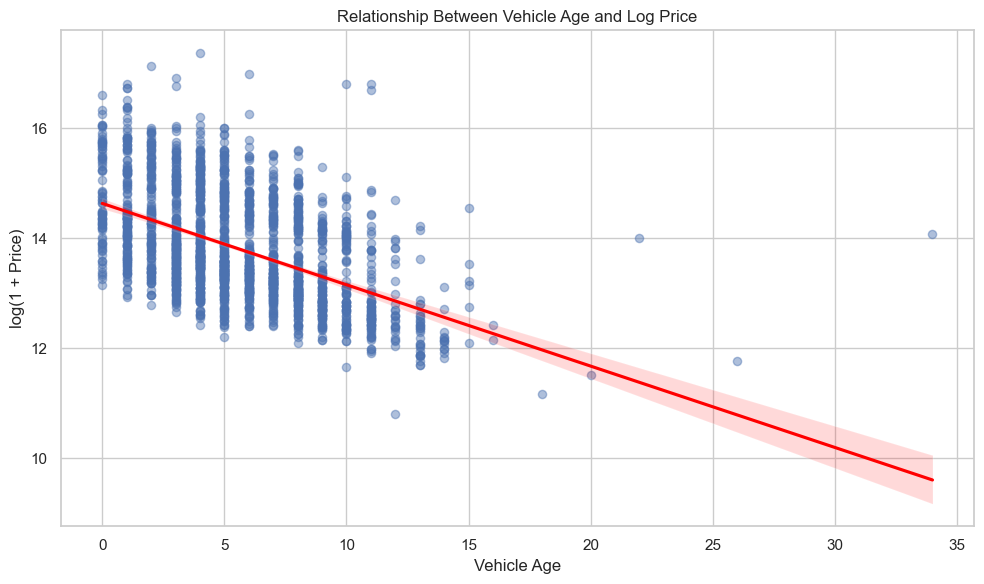

In [14]:
df["Log Price"] = np.log1p(df["Price"])

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="Vehicle Age",
    y="Log Price",
    scatter_kws={
        "alpha": 0.45,
        "s": 35
    },
    line_kws={
        "color": "red"
    }
)

plt.title("Relationship Between Vehicle Age and Log Price")
plt.xlabel("Vehicle Age")
plt.ylabel("log(1 + Price)")

plt.tight_layout()

plt.savefig(
    "../results/figures/vehicle_age_vs_log_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Vehicle-Age Relationship Finding

Vehicle Age has a clear negative association with Log Price. Newer vehicles
generally have higher prices, while older vehicles tend to have lower prices.

The wide vertical spread at each age shows that depreciation is not the only
determinant of Price. Brand, model, technical specifications, location, and
other characteristics are also important.

The uncertainty band becomes wider for older vehicles because relatively few
old vehicles are available in the dataset. Some older vehicles also retain
unusually high prices and require contextual investigation.

### 7.1 Vehicle-Age Correlation with Price

Pearson correlation measures linear association, while Spearman correlation
measures monotonic rank-based association.

Both are calculated because raw Price contains extreme luxury values.

In [15]:
age_price_pearson = df["Vehicle Age"].corr(
    df["Price"],
    method="pearson"
)

age_log_price_pearson = df["Vehicle Age"].corr(
    df["Log Price"],
    method="pearson"
)

age_price_spearman = df["Vehicle Age"].corr(
    df["Price"],
    method="spearman"
)

print(
    "Pearson correlation: Vehicle Age vs Price:",
    round(age_price_pearson, 3)
)

print(
    "Pearson correlation: Vehicle Age vs Log Price:",
    round(age_log_price_pearson, 3)
)

print(
    "Spearman correlation: Vehicle Age vs Price:",
    round(age_price_spearman, 3)
)

Pearson correlation: Vehicle Age vs Price: -0.311
Pearson correlation: Vehicle Age vs Log Price: -0.507
Spearman correlation: Vehicle Age vs Price: -0.52


### Vehicle-Age Correlation Finding

Vehicle Age has a moderate negative relationship with vehicle Price.

The Pearson correlation becomes stronger after applying the logarithmic Price
transformation, changing from -0.311 to -0.507. The Spearman correlation of
-0.520 provides similar evidence of a monotonic depreciation pattern.

This supports evaluating Log Price as a modeling target because it produces
a more linear relationship with Vehicle Age.

## 8. Relationship Between Kilometer and Price

Mileage is expected to have a negative association with vehicle Price.
However, a small number of extreme Kilometer values may distort the apparent
linear relationship.

The complete data and the main 99-percent range are visualized separately.

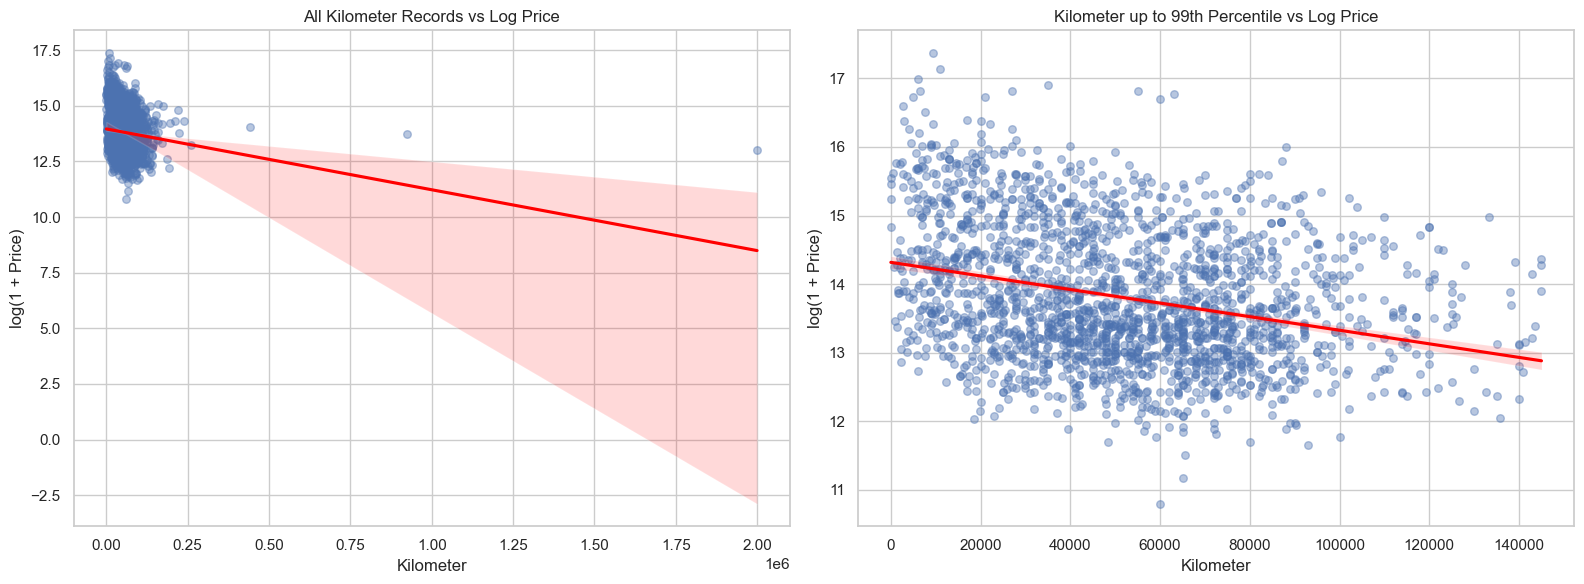

In [16]:
main_kilometer_data = df[
    df["Kilometer"] <= kilometer_99
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(
    data=df,
    x="Kilometer",
    y="Log Price",
    scatter_kws={
        "alpha": 0.40,
        "s": 30
    },
    line_kws={
        "color": "red"
    },
    ax=axes[0]
)

axes[0].set_title("All Kilometer Records vs Log Price")
axes[0].set_xlabel("Kilometer")
axes[0].set_ylabel("log(1 + Price)")

sns.regplot(
    data=main_kilometer_data,
    x="Kilometer",
    y="Log Price",
    scatter_kws={
        "alpha": 0.40,
        "s": 30
    },
    line_kws={
        "color": "red"
    },
    ax=axes[1]
)

axes[1].set_title("Kilometer up to 99th Percentile vs Log Price")
axes[1].set_xlabel("Kilometer")
axes[1].set_ylabel("log(1 + Price)")

plt.tight_layout()

plt.savefig(
    "../results/figures/kilometer_vs_log_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Kilometer–Price Relationship Finding

The full-data regression line is strongly affected by a very small number
of extreme Kilometer observations. These records produce a wide uncertainty
band and an unstable visual trend.

After restricting the visualization to the 99th percentile, a clearer
negative relationship appears: vehicles with higher mileage generally have
lower prices.

The substantial vertical spread indicates that mileage alone is insufficient
to explain Price. Brand, age, model, engine characteristics, and other
features must also be considered.

The extreme Kilometer records are potential high-leverage observations and
their influence will be evaluated through model diagnostics and sensitivity
experiments.